# Gradient Descent for Logistic Regression
# 로지스틱 회귀 경사하강법

## Goal

- Implement gradient descent.
- 경사하강법 구현

- Update w and b automatically.
- w, b 자동 업데이트

- Reduce cost step by step.
- cost를 반복적으로 감소시키기

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 데이터 준비
X_train = np.array([
    [0.5, 1.5],
    [1.0, 1.0],
    [1.5, 0.5],
    [3.0, 0.5],
    [2.0, 2.0],
    [1.0, 2.5]
])

y_train = np.array([0, 0, 0, 1, 1, 1])

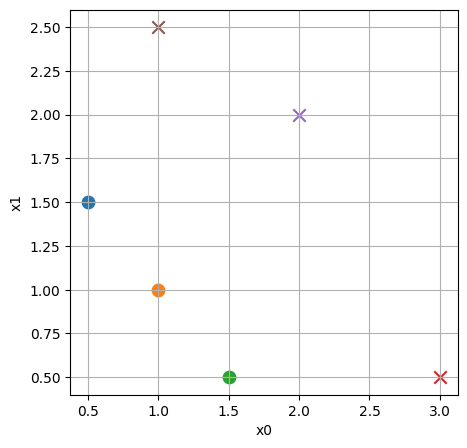

In [4]:
plt.figure(figsize=(5, 5))

for i in range(len(y_train)):
    if y_train[i] == 1:
        plt.scatter(X_train[i, 0], X_train[i, 1], marker='x', s=80)
    else:
        plt.scatter(X_train[i, 0], X_train[i, 1], marker='o', s=80)

plt.xlabel("x0")
plt.ylabel("x1")
plt.grid(True)
plt.show()

In [5]:
# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
# 예측 함수
def predict(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

In [7]:
# Cost Function
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0

    for i in range(m):
        fx = predict(X[i], w, b)
        loss = -(y[i] * np.log(fx) + (1 - y[i]) * np.log(1 - fx))
        cost += loss
    
    return cost / m

In [8]:
# Gradient 계산
def compute_gradient(X, y, w, b):
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        fx = predict(X[i], w, b)
        err = fx - y[i]

        for j in range(n):
            dj_dw[j] += err * X[i, j]
        
        dj_db += err
    
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [9]:
def gradient_descent(X, y, w, b, alpha, iters):

    J_history = []

    for i in range(iters):

        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        J_history.append(cost)

        if i % 1000 == 0:
            print(f"Iteration {i}: Cost {cost:.4f}")
    
    return w, b, J_history

In [29]:
w = np.zeros(2)
b = 0.

alpha = 0.1
iters = 10000

In [30]:
# 학습 실행
w_out, b_out, J_hist = gradient_descent(
    X_train, y_train, w, b, alpha, iters
)

print("w =", w_out)
print("b =", b_out)

Iteration 0: Cost 0.6846
Iteration 1000: Cost 0.1591
Iteration 2000: Cost 0.0846
Iteration 3000: Cost 0.0571
Iteration 4000: Cost 0.0429
Iteration 5000: Cost 0.0343
Iteration 6000: Cost 0.0286
Iteration 7000: Cost 0.0245
Iteration 8000: Cost 0.0214
Iteration 9000: Cost 0.0190
w = [5.28123029 5.07815608]
b = -14.222409982019837


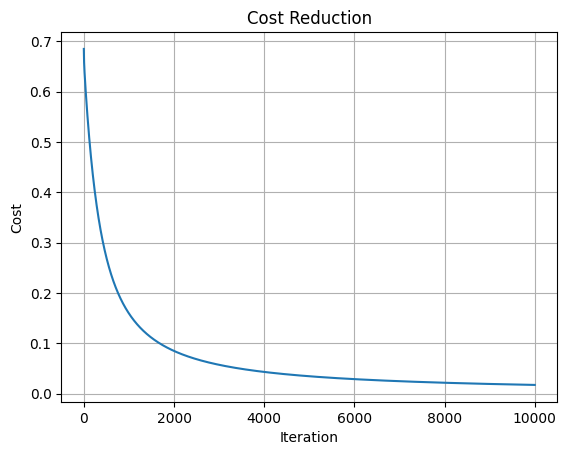

In [12]:
plt.plot(J_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Reduction")
plt.grid(True)
plt.show()

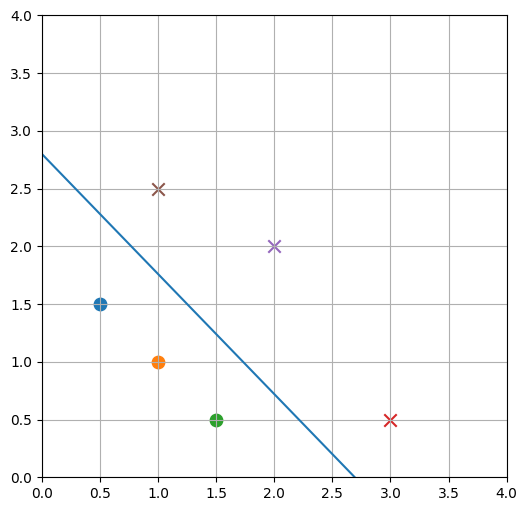

In [16]:
# Decision Boundary
x0 = np.linspace(0, 4, 100)
x1 = -(w_out[0] * x0 + b_out)/w_out[1]

plt.figure(figsize=(6,6))
plt.plot(x0, x1)

for i in range(len(y_train)):
    if y_train[i] == 1:
        plt.scatter(X_train[i, 0], X_train[i, 1], marker='x', s=80)
    else:
        plt.scatter(X_train[i, 0], X_train[i, 1], marker='o', s=80)

plt.xlim(0, 4)
plt.ylim(0, 4)
plt.grid(True)
plt.show()

## What heppend?

Gradient descent changed w and b step by step.

경사하강법이 w, b를 조금씩 수정했다.

The cost became smaller.

cost가 점점 작아졌다.

A good decision boundary was found.

좋은 결정 경계를 찾았다.